In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pymatgen.electronic_structure.core import Orbital, OrbitalType, Spin
from pymatgen.core.periodic_table import Element, Species

import time

# Import relevant data
basicinfofile = "../Analysis/HDP_BasicInfo_260510.csv"
bandedgefile_lso = "../AnalysisResults/HDP_bandedgeInfo_lsodos_260510.csv"


qualityoverviewfile = "../AnalysisResults/HDP_lobqual_overview_260509.csv"
largespillfile = "../AnalysisResults/HDPs_SpillOver3_260509.csv"

output_dir = "."

/home/lwalterb/hdp_project/NewWF_Analysis/CsBBX_Analyzer.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


hello0


In [ ]:
##Import quality analysis from saved csv
quality_df = pd.read_csv(qualityoverviewfile, index_col=[0, 1])

##import which comps have charge spilling > 3% in basis0
b0qual_df = quality_df.xs("basisset0", level=1)
badqualcomps = pd.read_csv(largespillfile, index_col=[0, 1])

In [ ]:
##Collect the quality of the basis actually used
usedqual = b0qual_df.reset_index().set_index("comp").copy()

for comp in badqualcomps.index.get_level_values(0):
    pos_choices = badqualcomps.loc[comp]
    corr_basis = pos_choices[
        pos_choices["abs_charge_spilling"] == pos_choices["abs_charge_spilling"].min()
    ].index.to_list()[0]
    usedqual.loc[comp] = quality_df.loc[(comp, corr_basis)]

print(usedqual.shape)
print(b0qual_df.shape)

(2583, 4)
(2583, 4)


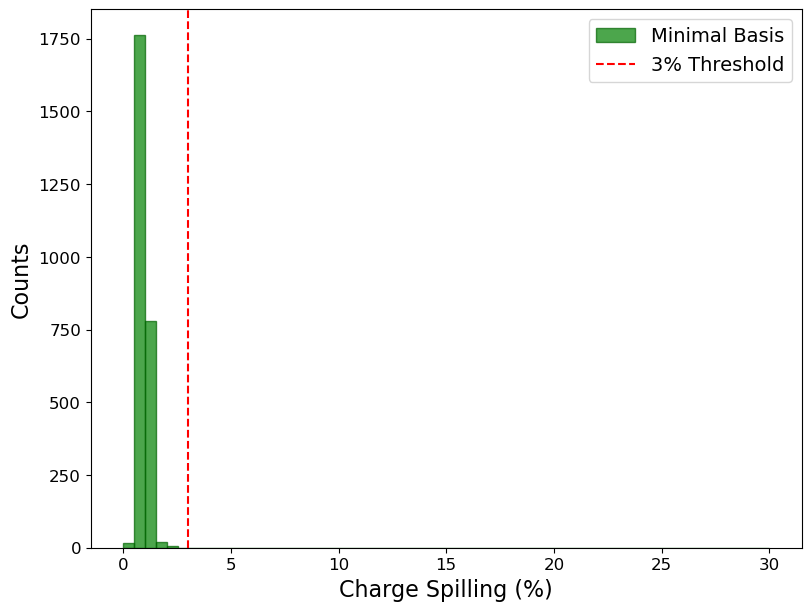

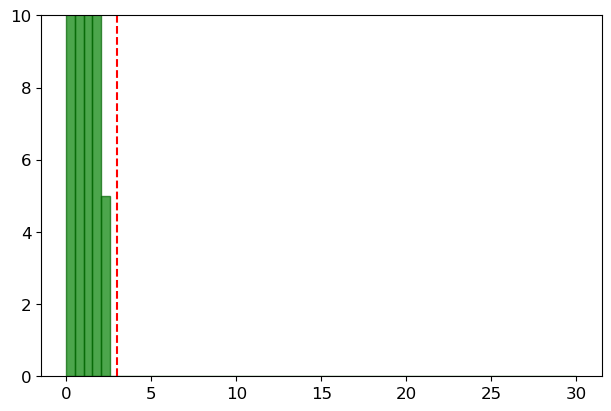

In [ ]:
##Plot the charge spilling for each comp
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)
plt.figure(figsize=(8, 6), layout="constrained")
binning = np.linspace(0, 30, 60)
plt.hist(
    "abs_charge_spilling",
    color="green",
    bins=binning,
    linewidth=1.0,
    edgecolor="darkgreen",
    data=usedqual,
    alpha=0.7,
    label="Minimal Basis",
)
# plt.hist('abs_charge_spilling', color='blue',bins=binning, data=b0qual_df,alpha=0.1, facecolor='red',linewidth=1.3,edgecolor='red', linestyle= '--' , label='Min. Basis only')
plt.axvline(x=3, color="red", linestyle="--", label="3% Threshold")
plt.ylabel("Counts", fontsize=16)
plt.xlabel("Charge Spilling (%)", fontsize=16)
# plt.title('Charge Spilling in LOBSTER projection', fontsize=16)
leg = plt.legend(fontsize=14)
# plt.tight_layout()
plt.savefig(f'{output_dir}/LobQualHist_{time.strftime("%d%m%y")}.png')
plt.show()

# zoomed in plot
plt.figure(figsize=(6, 4), layout="constrained")
binning = np.linspace(0, 30, 60)
plt.hist(
    "abs_charge_spilling",
    color="green",
    bins=binning,
    data=usedqual,
    linewidth=1.0,
    edgecolor="darkgreen",
    alpha=0.7,
    label="Minimal Basis",
)
# plt.hist('abs_charge_spilling', color='blue',bins=binning, data=b0qual_df,alpha=0.1, facecolor='red',linewidth=1.3,edgecolor='red', linestyle= '--' , label='Min. Basis only')
plt.axvline(x=3, color="red", linestyle="--", label="3% Threshold")
# plt.ylabel('Counts', fontsize=16)
# plt.xlabel('Charge Spilling (%)', fontsize=16)
# plt.tight_layout()
plt.ylim([0, 10])
plt.savefig(f'{output_dir}/LobQualHist_zoom_{time.strftime("%d%m%y")}.png')
plt.show()